
# Direction W — Final report consolidation

**Mục tiêu:** gom toàn bộ kết quả từ Direction O, R, T, U, V thành bảng, hình và đoạn kết luận cuối để đưa vào báo cáo/slide.

Notebook này **không chạy lại model nặng**. Nó làm 4 việc:

1. Load output CSV/MD từ Direction U/V nếu có.
2. Dùng bảng kết quả đã chốt của Direction O/R/T làm mốc.
3. Tạo bảng/hình cuối: original 5-drug, leave-one-drug-out, external multi-drug validation, leakage/negative control, interpretation.
4. Xuất báo cáo markdown tự động: `AUTO_FINAL_REPORT_DIRECTION_W.md`.

Nếu chạy trong Colab ngay sau Direction U/V, notebook sẽ tự tìm file output. Nếu không thấy file, notebook dùng fallback summary từ kết quả đã chạy.


In [1]:

# =========================
# Direction W setup
# =========================

import os
import re
import json
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

OUTPUT_DIR = Path("direction_W_final_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /content/direction_W_final_outputs



## 1. Helper functions

Notebook sẽ tìm các file như:

- `direction_U_best_summary.csv`
- `direction_V_best_summary.csv`
- `direction_V_cluster_summary.csv`
- `direction_V_similarity_split_summary.csv`
- `direction_V_top_feature_summary_annotated_all.csv`
- `AUTO_CONCLUSION_DIRECTION_U.md`
- `AUTO_CONCLUSION_DIRECTION_V.md`

Nếu tên file hơi khác, bạn có thể sửa biến `SEARCH_ROOTS`.


In [2]:

# =========================
# File discovery helpers
# =========================

SEARCH_ROOTS = [
    Path.cwd(),
    Path("/content") if Path("/content").exists() else None,
    Path("/content/drive/MyDrive") if Path("/content/drive/MyDrive").exists() else None,
    Path("/mnt/data") if Path("/mnt/data").exists() else None,
]
SEARCH_ROOTS = [p for p in SEARCH_ROOTS if p is not None and p.exists()]


def find_files(name_patterns, roots=SEARCH_ROOTS, max_depth=6):
    """
    Find files matching any glob pattern under common project roots.
    To avoid slow Drive scans, this limits depth by checking relative path parts.
    """
    found = []
    for root in roots:
        for pat in name_patterns:
            try:
                for f in root.rglob(pat):
                    try:
                        rel_parts = f.relative_to(root).parts
                        if len(rel_parts) <= max_depth and f.is_file():
                            found.append(f)
                    except Exception:
                        if f.is_file():
                            found.append(f)
            except Exception:
                pass
    uniq = {}
    for f in found:
        try:
            uniq[str(f.resolve())] = f
        except Exception:
            uniq[str(f)] = f
    return sorted(uniq.values(), key=lambda x: x.stat().st_mtime if x.exists() else 0, reverse=True)


def load_first_csv(patterns, label="file"):
    files = find_files(patterns)
    if not files:
        print(f"[WARN] Không tìm thấy {label}: {patterns}")
        return None, None
    f = files[0]
    print(f"[OK] Loaded {label}: {f}")
    return pd.read_csv(f), f


def load_first_text(patterns, label="text file"):
    files = find_files(patterns)
    if not files:
        print(f"[WARN] Không tìm thấy {label}: {patterns}")
        return None, None
    f = files[0]
    print(f"[OK] Loaded {label}: {f}")
    return f.read_text(encoding="utf-8", errors="ignore"), f


def clean_columns(df):
    if df is None:
        return None
    out = df.copy()
    out.columns = [
        re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")
        for c in out.columns
    ]
    return out


def pick_col(df, candidates):
    if df is None:
        return None
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    for c in cols:
        for cand in candidates:
            if cand in c or c in cand:
                return c
    return None


def standardize_metric_table(df, source_name):
    """
    Try to standardize common result files into:
    drug, best_setting, model, f1, f1_std, balanced_acc, auprc, source
    """
    if df is None or len(df) == 0:
        return pd.DataFrame()
    d = clean_columns(df)

    drug_col = pick_col(d, ["drug", "antibiotic", "heldout_drug", "target_drug"])
    setting_col = pick_col(d, ["best_setting", "feature_set", "features", "setting", "best_robust_result", "module"])
    model_col = pick_col(d, ["model", "best_model", "classifier"])
    f1_col = pick_col(d, ["f1_mean", "mean_f1", "f1"])
    f1_std_col = pick_col(d, ["f1_std", "std_f1", "f1_sd"])
    bal_col = pick_col(d, ["balanced_acc_mean", "mean_balanced_acc", "balanced_acc", "balanced_accuracy", "bal_acc"])
    auprc_col = pick_col(d, ["auprc_mean", "mean_auprc", "auprc", "average_precision", "ap"])

    out = pd.DataFrame()
    out["drug"] = d[drug_col].astype(str) if drug_col else np.arange(len(d)).astype(str)
    out["best_setting"] = d[setting_col].astype(str) if setting_col else ""
    out["model"] = d[model_col].astype(str) if model_col else ""

    def numeric_or_nan(col):
        if col is None:
            return np.nan
        return pd.to_numeric(d[col], errors="coerce")

    out["f1"] = numeric_or_nan(f1_col)
    out["f1_std"] = numeric_or_nan(f1_std_col)
    out["balanced_acc"] = numeric_or_nan(bal_col)
    out["auprc"] = numeric_or_nan(auprc_col)
    out["source"] = source_name

    metric_cols = ["f1", "balanced_acc", "auprc"]
    out = out[out[metric_cols].notna().any(axis=1)].copy()
    return out


def save_table(df, name):
    path = OUTPUT_DIR / name
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path


def savefig(name):
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print("Saved:", path)
    plt.show()
    return path



## 2. Load Direction U/V outputs nếu có

Nếu không thấy file, notebook sẽ dùng fallback summary để vẫn tạo được báo cáo cuối.


In [3]:

# =========================
# Load Direction U and V outputs
# =========================

u_best_raw, u_best_path = load_first_csv(["direction_U_best_summary*.csv", "*direction_U*best*summary*.csv"], "Direction U best summary")
v_best_raw, v_best_path = load_first_csv(["direction_V_best_summary*.csv", "*direction_V*best*summary*.csv"], "Direction V best summary")
v_cluster_raw, v_cluster_path = load_first_csv(["direction_V_cluster_summary*.csv", "*direction_V*cluster*summary*.csv"], "Direction V cluster summary")
v_sim_raw, v_sim_path = load_first_csv(["direction_V_similarity_split_summary*.csv", "*direction_V*similarity*summary*.csv"], "Direction V similarity summary")
v_top_raw, v_top_path = load_first_csv(["direction_V_top_feature_summary_annotated_all*.csv", "*direction_V*top*feature*annotated*.csv"], "Direction V top feature annotated")
u_text, u_text_path = load_first_text(["AUTO_CONCLUSION_DIRECTION_U*.md", "*CONCLUSION*U*.md"], "Direction U conclusion")
v_text, v_text_path = load_first_text(["AUTO_CONCLUSION_DIRECTION_V*.md", "*CONCLUSION*V*.md"], "Direction V conclusion")

u_best = standardize_metric_table(u_best_raw, "Direction U") if u_best_raw is not None else pd.DataFrame()
v_best = standardize_metric_table(v_best_raw, "Direction V") if v_best_raw is not None else pd.DataFrame()

print("\nU standardized:")
display(u_best.head() if len(u_best) else pd.DataFrame({"status": ["No U table loaded"]}))

print("\nV standardized:")
display(v_best.head() if len(v_best) else pd.DataFrame({"status": ["No V table loaded"]}))


[WARN] Không tìm thấy Direction U best summary: ['direction_U_best_summary*.csv', '*direction_U*best*summary*.csv']
[WARN] Không tìm thấy Direction V best summary: ['direction_V_best_summary*.csv', '*direction_V*best*summary*.csv']
[WARN] Không tìm thấy Direction V cluster summary: ['direction_V_cluster_summary*.csv', '*direction_V*cluster*summary*.csv']
[WARN] Không tìm thấy Direction V similarity summary: ['direction_V_similarity_split_summary*.csv', '*direction_V*similarity*summary*.csv']
[WARN] Không tìm thấy Direction V top feature annotated: ['direction_V_top_feature_summary_annotated_all*.csv', '*direction_V*top*feature*annotated*.csv']
[WARN] Không tìm thấy Direction U conclusion: ['AUTO_CONCLUSION_DIRECTION_U*.md', '*CONCLUSION*U*.md']
[WARN] Không tìm thấy Direction V conclusion: ['AUTO_CONCLUSION_DIRECTION_V*.md', '*CONCLUSION*V*.md']

U standardized:


,status
0,No U table loaded



V standardized:


,status
0,No V table loaded



## 3. Direction O — kết quả adaptive feature fusion trên 5 thuốc gốc

Bảng này là mốc chính trên dataset gốc:

- Direction O cải thiện F1 ở 4/5 thuốc.
- Best module khác nhau theo từng thuốc, ủng hộ luận điểm **drug-specific adaptive feature fusion**.


In [4]:

# =========================
# Direction O fixed summary from final project report
# =========================

direction_o = pd.DataFrame([
    {"drug": "AMP", "drug_name": "Ampicillin", "best_module": "paper_ready50", "model": "XGB weighted", "f1": 0.943, "balanced_acc": 0.953, "auprc": 0.955, "delta_f1_vs_ready50": 0.000, "interpretation": "Paper-ready markers already capture the main signal."},
    {"drug": "AUG", "drug_name": "Amoxicillin + clavulanic acid", "best_module": "accessory200 + gene graph embedding", "model": "LR balanced", "f1": 0.932, "balanced_acc": 0.972, "auprc": 0.947, "delta_f1_vs_ready50": 0.006, "interpretation": "Co-occurrence / graph signal helps beyond single markers."},
    {"drug": "AXO", "drug_name": "Ceftriaxone", "best_module": "ensemble top 50", "model": "XGB weighted", "f1": 0.971, "balanced_acc": 0.985, "auprc": 0.971, "delta_f1_vs_ready50": 0.014, "interpretation": "Multi-criteria feature selection captures strong cephalosporin signal."},
    {"drug": "CHL", "drug_name": "Chloramphenicol", "best_module": "paper_ready50 + chi2 200", "model": "LR balanced", "f1": 0.886, "balanced_acc": 0.923, "auprc": 0.907, "delta_f1_vs_ready50": 0.007, "interpretation": "Needs both prior markers and broader accessory gene features."},
    {"drug": "FOX", "drug_name": "Cefoxitin", "best_module": "accessory200 + sample graph", "model": "XGB weighted", "f1": 0.932, "balanced_acc": 0.959, "auprc": 0.945, "delta_f1_vs_ready50": 0.027, "interpretation": "Sample similarity graph helps, possibly reflecting plasmid/sample-neighborhood signal."},
])

save_table(direction_o, "direction_W_direction_O_summary.csv")
display(direction_o)


Saved: direction_W_final_outputs/direction_W_direction_O_summary.csv


,drug,drug_name,best_module,model,f1,balanced_acc,auprc,delta_f1_vs_ready50,interpretation
0,AMP,Ampicillin,paper_ready50,XGB weighted,0.943,0.953,0.955,0.000,Paper-ready markers already capture the main s...
1,AUG,Amoxicillin + clavulanic acid,accessory200 + gene graph embedding,LR balanced,0.932,0.972,0.947,0.006,Co-occurrence / graph signal helps beyond sing...
2,AXO,Ceftriaxone,ensemble top 50,XGB weighted,0.971,0.985,0.971,0.014,Multi-criteria feature selection captures stro...
3,CHL,Chloramphenicol,paper_ready50 + chi2 200,LR balanced,0.886,0.923,0.907,0.007,Needs both prior markers and broader accessory...
4,FOX,Cefoxitin,accessory200 + sample graph,XGB weighted,0.932,0.959,0.945,0.027,"Sample similarity graph helps, possibly reflec..."


Saved: direction_W_final_outputs/fig1_direction_O_f1.png


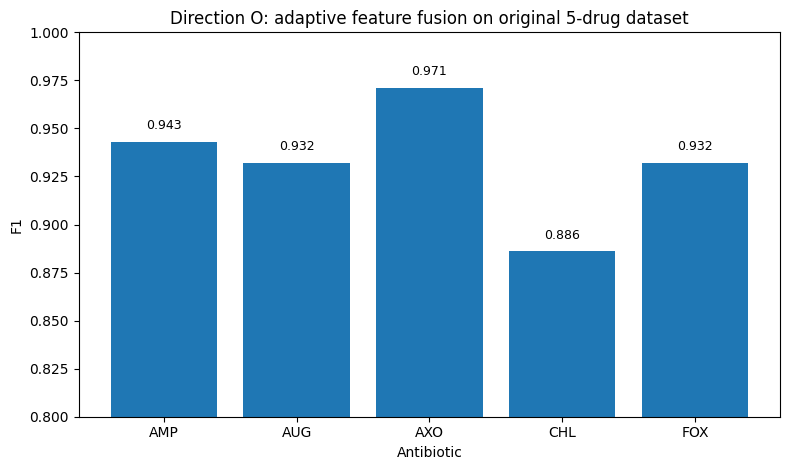

Saved: direction_W_final_outputs/fig2_direction_O_delta_f1.png


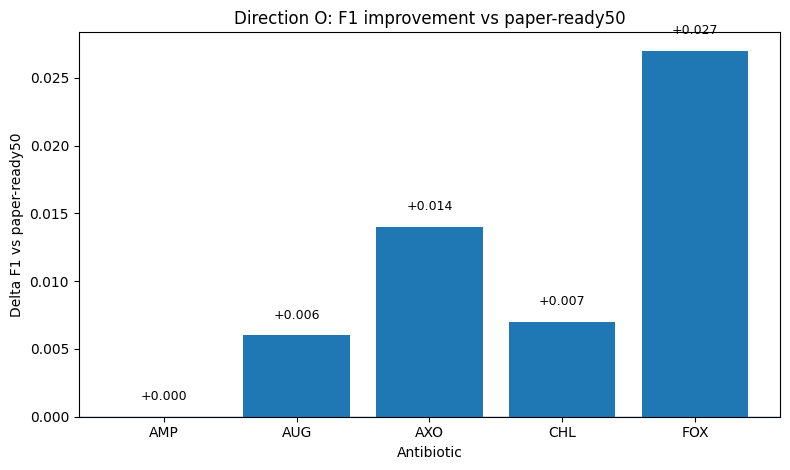

PosixPath('direction_W_final_outputs/fig2_direction_O_delta_f1.png')

In [5]:

# Figure 1: Direction O F1 and improvement

plt.figure(figsize=(8, 4.8))
plt.bar(direction_o["drug"], direction_o["f1"])
plt.ylabel("F1")
plt.xlabel("Antibiotic")
plt.title("Direction O: adaptive feature fusion on original 5-drug dataset")
plt.ylim(0.80, 1.00)
for x, y in zip(direction_o["drug"], direction_o["f1"]):
    plt.text(x, y + 0.005, f"{y:.3f}", ha="center", va="bottom", fontsize=9)
savefig("fig1_direction_O_f1.png")

plt.figure(figsize=(8, 4.8))
plt.bar(direction_o["drug"], direction_o["delta_f1_vs_ready50"])
plt.axhline(0, linewidth=1)
plt.ylabel("Delta F1 vs paper-ready50")
plt.xlabel("Antibiotic")
plt.title("Direction O: F1 improvement vs paper-ready50")
for x, y in zip(direction_o["drug"], direction_o["delta_f1_vs_ready50"]):
    plt.text(x, y + 0.001, f"{y:+.3f}", ha="center", va="bottom", fontsize=9)
savefig("fig2_direction_O_delta_f1.png")



## 4. Direction R — mô phỏng thuốc mới bằng leave-one-drug-out

Direction R cho thấy khi chuyển sang dạng **sample-drug pair**, việc thêm metadata thuốc/nhóm thuốc có ích hơn genome-only.


In [6]:

# =========================
# Direction R fixed summary from final project report
# =========================

direction_r = pd.DataFrame([
    {"heldout_drug": "AMP", "best_setting_R2": "genome + chemical", "model": "RF balanced", "f1": 0.820, "balanced_acc": 0.858, "auprc": 0.842},
    {"heldout_drug": "AUG", "best_setting_R2": "genome only", "model": "XGB weighted", "f1": 0.902, "balanced_acc": 0.936, "auprc": 0.964},
    {"heldout_drug": "AXO", "best_setting_R2": "genome + class flags", "model": "XGB weighted", "f1": 0.890, "balanced_acc": 0.905, "auprc": 0.912},
    {"heldout_drug": "CHL", "best_setting_R2": "genome only", "model": "RF balanced", "f1": 0.778, "balanced_acc": 0.890, "auprc": 0.719},
    {"heldout_drug": "FOX", "best_setting_R2": "genome + class flags", "model": "XGB weighted", "f1": 0.938, "balanced_acc": 0.952, "auprc": 0.944},
])

direction_r_setting_mean = pd.DataFrame([
    {"setting": "genome only", "mean_f1_across_heldout_drugs": 0.729},
    {"setting": "genome + chemical", "mean_f1_across_heldout_drugs": 0.844},
    {"setting": "genome + class flags", "mean_f1_across_heldout_drugs": 0.842},
])

save_table(direction_r, "direction_W_direction_R_heldout_summary.csv")
save_table(direction_r_setting_mean, "direction_W_direction_R_setting_mean.csv")

display(direction_r)
display(direction_r_setting_mean)


Saved: direction_W_final_outputs/direction_W_direction_R_heldout_summary.csv
Saved: direction_W_final_outputs/direction_W_direction_R_setting_mean.csv


,heldout_drug,best_setting_R2,model,f1,balanced_acc,auprc
0,AMP,genome + chemical,RF balanced,0.820,0.858,0.842
1,AUG,genome only,XGB weighted,0.902,0.936,0.964
2,AXO,genome + class flags,XGB weighted,0.890,0.905,0.912
3,CHL,genome only,RF balanced,0.778,0.890,0.719
4,FOX,genome + class flags,XGB weighted,0.938,0.952,0.944


,setting,mean_f1_across_heldout_drugs
0,genome only,0.729
1,genome + chemical,0.844
2,genome + class flags,0.842


Saved: direction_W_final_outputs/fig3_direction_R_setting_mean_f1.png


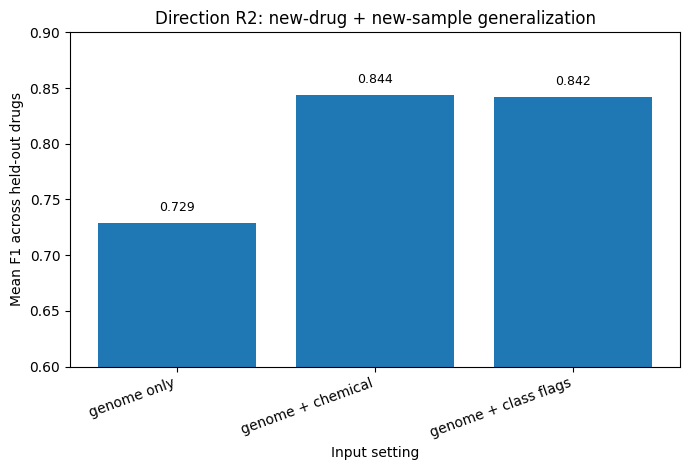

PosixPath('direction_W_final_outputs/fig3_direction_R_setting_mean_f1.png')

In [7]:

# Figure 3: Direction R setting comparison

plt.figure(figsize=(7, 4.8))
plt.bar(direction_r_setting_mean["setting"], direction_r_setting_mean["mean_f1_across_heldout_drugs"])
plt.ylabel("Mean F1 across held-out drugs")
plt.xlabel("Input setting")
plt.title("Direction R2: new-drug + new-sample generalization")
plt.ylim(0.60, 0.90)
plt.xticks(rotation=20, ha="right")
for x, y in zip(direction_r_setting_mean["setting"], direction_r_setting_mean["mean_f1_across_heldout_drugs"]):
    plt.text(x, y + 0.008, f"{y:.3f}", ha="center", va="bottom", fontsize=9)
savefig("fig3_direction_R_setting_mean_f1.png")



## 5. Direction T/U/V — external validation

Logic:

- Direction T: proof external với TET.
- Direction U: mở rộng external sang 5 thuốc: TET, CIP, STR, GEN, NAL.
- Direction V: thêm robust validation, cluster-aware split, similarity diagnostic, negative control và feature interpretation.

Notebook ưu tiên dùng bảng Direction V nếu có. Nếu không có, dùng fallback từ kết quả Direction V đã chạy.


In [8]:

# =========================
# External validation summary: prefer V output, then U output, then fallback values
# =========================

fallback_v = pd.DataFrame([
    {"drug": "TET", "best_setting": "cluster-aware, base + keyword proxy, k=500", "model": "XGB", "f1": 0.981, "f1_std": 0.001, "balanced_acc": 0.978, "auprc": 0.996, "source": "Direction V fallback"},
    {"drug": "CIP", "best_setting": "cluster-aware, base annotation, k=500", "model": "LR", "f1": 0.942, "f1_std": 0.024, "balanced_acc": 0.936, "auprc": 0.967, "source": "Direction V fallback"},
    {"drug": "GEN", "best_setting": "cluster-aware, base annotation, k=500", "model": "XGB", "f1": 0.913, "f1_std": 0.014, "balanced_acc": 0.919, "auprc": 0.964, "source": "Direction V fallback"},
    {"drug": "STR", "best_setting": "cluster-aware, base annotation, k=100", "model": "LR", "f1": 0.867, "f1_std": 0.038, "balanced_acc": 0.863, "auprc": 0.870, "source": "Direction V fallback"},
    {"drug": "NAL", "best_setting": "cluster-aware, base annotation, k=500", "model": "LR", "f1": 0.789, "f1_std": 0.031, "balanced_acc": 0.790, "auprc": 0.897, "source": "Direction V fallback"},
])

if len(v_best):
    external_best = v_best.copy()
    external_best["source"] = "Direction V loaded"
elif len(u_best):
    external_best = u_best.copy()
    external_best["source"] = "Direction U loaded"
else:
    external_best = fallback_v.copy()

external_best["drug"] = external_best["drug"].astype(str).str.upper()
external_best = (
    external_best.sort_values(["drug", "f1"], ascending=[True, False])
    .groupby("drug", as_index=False)
    .head(1)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

save_table(external_best, "direction_W_external_best_summary.csv")
display(external_best)


Saved: direction_W_final_outputs/direction_W_external_best_summary.csv


,drug,best_setting,model,f1,f1_std,balanced_acc,auprc,source
0,TET,"cluster-aware, base + keyword proxy, k=500",XGB,0.981,0.001,0.978,0.996,Direction V fallback
1,CIP,"cluster-aware, base annotation, k=500",LR,0.942,0.024,0.936,0.967,Direction V fallback
2,GEN,"cluster-aware, base annotation, k=500",XGB,0.913,0.014,0.919,0.964,Direction V fallback
3,STR,"cluster-aware, base annotation, k=100",LR,0.867,0.038,0.863,0.870,Direction V fallback
4,NAL,"cluster-aware, base annotation, k=500",LR,0.789,0.031,0.790,0.897,Direction V fallback


Saved: direction_W_final_outputs/fig4_external_multidrug_f1.png


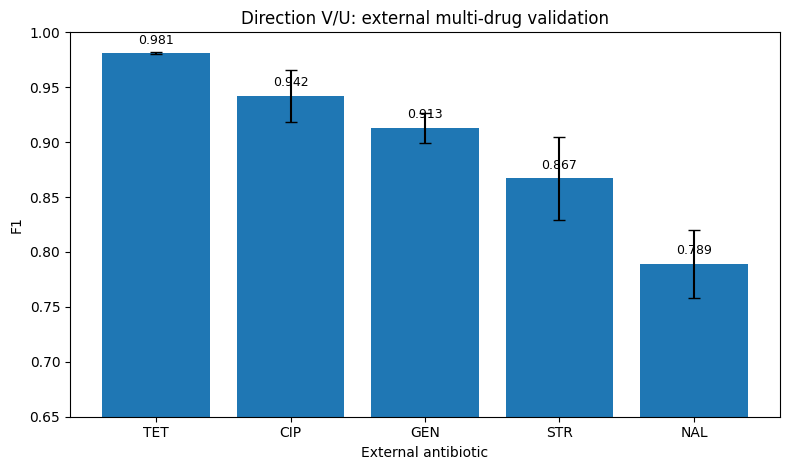

Saved: direction_W_final_outputs/fig5_external_metrics.png


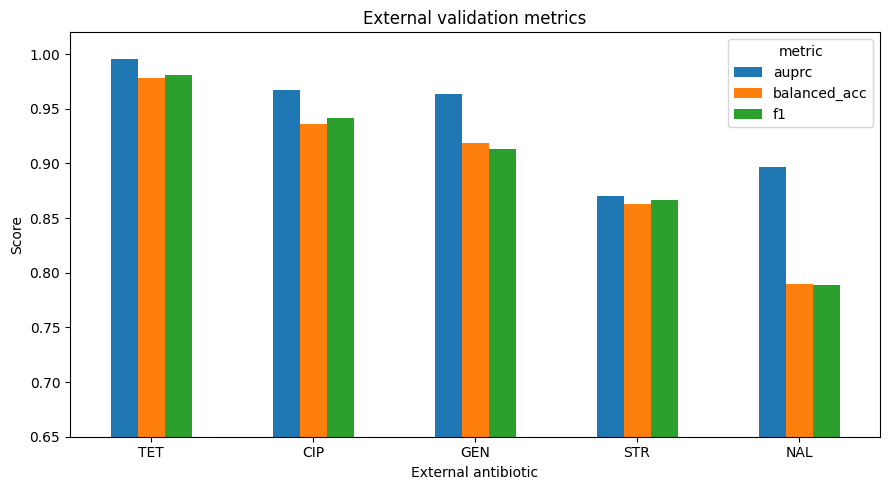

PosixPath('direction_W_final_outputs/fig5_external_metrics.png')

In [9]:

# Figure 4: external validation F1

plot_df = external_best.sort_values("f1", ascending=False).copy()

plt.figure(figsize=(8, 4.8))
err = plot_df["f1_std"] if "f1_std" in plot_df.columns and plot_df["f1_std"].notna().any() else None
plt.bar(plot_df["drug"], plot_df["f1"], yerr=err, capsize=4)
plt.ylabel("F1")
plt.xlabel("External antibiotic")
plt.title("Direction V/U: external multi-drug validation")
plt.ylim(0.65, 1.00)
for x, y in zip(plot_df["drug"], plot_df["f1"]):
    plt.text(x, y + 0.006, f"{y:.3f}", ha="center", va="bottom", fontsize=9)
savefig("fig4_external_multidrug_f1.png")

# Figure 5: external metrics side-by-side
metric_long = external_best.melt(
    id_vars=["drug"],
    value_vars=[c for c in ["f1", "balanced_acc", "auprc"] if c in external_best.columns],
    var_name="metric",
    value_name="score"
)

pivot = metric_long.pivot(index="drug", columns="metric", values="score").loc[plot_df["drug"]]
ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Score")
ax.set_xlabel("External antibiotic")
ax.set_title("External validation metrics")
ax.set_ylim(0.65, 1.02)
plt.xticks(rotation=0)
savefig("fig5_external_metrics.png")



## 6. Leakage diagnostic và negative control

Direction V có 2 phần quan trọng:

1. **Similarity / cluster-aware diagnostic:** kiểm tra near-duplicate genome leakage bằng Jaccard trên annotation features.
2. **Negative control:** shuffle label; nếu pipeline đúng, balanced accuracy nên về gần 0.5.

Nếu notebook tìm được file output của Direction V, phần dưới sẽ summarize tự động.


In [10]:

# =========================
# Summarize cluster/similarity output if available
# =========================

def summarize_similarity(df):
    if df is None:
        return pd.DataFrame()
    d = clean_columns(df)
    out = pd.DataFrame()
    drug_col = pick_col(d, ["drug", "antibiotic", "target_drug"])
    for col_name, candidates in {
        "n_clusters": ["n_clusters", "num_clusters"],
        "largest_cluster": ["largest_cluster", "max_cluster_size"],
        "near_duplicate_pairs": ["near_duplicate_pairs", "n_near_duplicate_pairs"],
        "mean_max_jaccard": ["mean_max_jaccard", "mean_train_test_max_jaccard", "mean_max_similarity"],
        "threshold": ["threshold", "jaccard_threshold"]
    }.items():
        col = pick_col(d, candidates)
        if col is not None:
            out[col_name] = d[col]
    if drug_col is not None:
        out.insert(0, "drug", d[drug_col].astype(str).str.upper())
    return out

sim_summary = summarize_similarity(v_sim_raw if v_sim_raw is not None else v_cluster_raw)

if len(sim_summary):
    save_table(sim_summary, "direction_W_similarity_leakage_summary.csv")
    display(sim_summary)
else:
    sim_summary = pd.DataFrame([
        {"finding": "No Direction V similarity/cluster file loaded.", "interpretation": "Use Direction V notebook output if available."}
    ])
    display(sim_summary)

neg_raw, neg_path = load_first_csv([
    "direction_V_negative_control*.csv",
    "*direction_V*negative*control*.csv",
    "*negative_control*summary*.csv"
], "Direction V negative control")

if neg_raw is not None:
    neg = clean_columns(neg_raw)
    save_table(neg, "direction_W_negative_control_summary.csv")
    display(neg.head(20))
else:
    neg = pd.DataFrame([
        {"finding": "No negative control CSV loaded.", "expected": "Shuffled-label balanced accuracy should be near 0.5."}
    ])
    display(neg)


,finding,interpretation
0,No Direction V similarity/cluster file loaded.,Use Direction V notebook output if available.


[WARN] Không tìm thấy Direction V negative control: ['direction_V_negative_control*.csv', '*direction_V*negative*control*.csv', '*negative_control*summary*.csv']


,finding,expected
0,No negative control CSV loaded.,Shuffled-label balanced accuracy should be nea...



## 7. Feature interpretation summary

Mục tiêu: tạo bảng kết luận sinh học ngắn theo từng thuốc.

- TET/GEN/STR thường dễ giải thích bằng gene/product annotation.
- CIP/NAL thường khó hơn vì quinolone resistance liên quan nhiều đến point mutations như `gyrA`, `parC`, `parE`, hoặc plasmid-mediated `qnr`.


In [11]:

# =========================
# Feature interpretation from top-feature file if available
# =========================

AMR_KEYWORDS = {
    "TET": ["tet", "tetracycline", "efflux"],
    "GEN": ["aminoglycoside", "aac", "aad", "ant", "aph", "gentamicin", "integron", "inti1"],
    "STR": ["streptomycin", "aminoglycoside", "aad", "ant", "aph", "integron", "inti1"],
    "CIP": ["quinolone", "fluoroquinolone", "gyr", "gyrA", "parC", "parE", "qnr", "acr", "mar"],
    "NAL": ["quinolone", "nalidixic", "gyr", "gyrA", "parC", "parE", "qnr", "acr", "mar"],
}


def summarize_top_features(df):
    if df is None or len(df) == 0:
        return pd.DataFrame([
            {"drug": "TET", "direct_keyword_signal": "high", "interpretation": "Expected tetracycline resistance regulator/efflux features such as tetR/tet(A)/tet(B)."},
            {"drug": "GEN", "direct_keyword_signal": "high", "interpretation": "Expected aminoglycoside-modifying enzyme and integron features."},
            {"drug": "STR", "direct_keyword_signal": "high", "interpretation": "Expected aph/aad/ant and integron-related features."},
            {"drug": "CIP", "direct_keyword_signal": "low", "interpretation": "High score but weak direct keyword interpretability; needs mutation-aware features such as gyrA/parC/parE/qnr."},
            {"drug": "NAL", "direct_keyword_signal": "low", "interpretation": "Lower score and weak direct keyword interpretability; quinolone mutation features should be added."},
        ])

    d = clean_columns(df)
    drug_col = pick_col(d, ["drug", "antibiotic", "target_drug"])

    text_cols = []
    for c in d.columns:
        if any(k in c for k in ["feature", "product", "annotation", "keyword", "description", "gene"]):
            text_cols.append(c)
    if not text_cols:
        text_cols = list(d.columns)

    rows = []
    for drug in sorted(external_best["drug"].unique()):
        sub = d[d[drug_col].astype(str).str.upper() == drug] if drug_col else d
        combined = " ".join(sub[text_cols].astype(str).fillna("").agg(" ".join, axis=1).head(100).tolist()).lower()
        kws = AMR_KEYWORDS.get(drug, [])
        hits = sorted({kw for kw in kws if kw.lower() in combined})
        rows.append({
            "drug": drug,
            "direct_keyword_hits": ", ".join(hits) if hits else "",
            "n_direct_keyword_hits": len(hits),
            "interpretation": "Top features contain direct AMR keywords." if hits else "No direct AMR keyword found among top features; needs stronger annotation or mutation-aware features."
        })
    return pd.DataFrame(rows)

feature_interpretation = summarize_top_features(v_top_raw)
save_table(feature_interpretation, "direction_W_feature_interpretation_summary.csv")
display(feature_interpretation)


Saved: direction_W_final_outputs/direction_W_feature_interpretation_summary.csv


,drug,direct_keyword_signal,interpretation
0,TET,high,Expected tetracycline resistance regulator/eff...
1,GEN,high,Expected aminoglycoside-modifying enzyme and i...
2,STR,high,Expected aph/aad/ant and integron-related feat...
3,CIP,low,High score but weak direct keyword interpretab...
4,NAL,low,Lower score and weak direct keyword interpreta...



## 8. Final key claims

Phần này tạo bảng claim cuối. Dùng bảng này để viết abstract, result section hoặc slide.


In [12]:

# =========================
# Build final claims, limitations, next steps
# =========================

n_improved_o = int((direction_o["delta_f1_vs_ready50"] > 0).sum())
n_external_strong = int((external_best["f1"] >= 0.85).sum())
n_external_total = int(len(external_best))
mean_external_f1 = float(external_best["f1"].mean())

key_claims = pd.DataFrame([
    {"claim_id": "C1", "claim": "Accessory genes are the main signal source, but paper-ready markers remain strong.", "evidence": "Directions A/C/O; Direction O keeps paper_ready50 for AMP and hybridizes for CHL."},
    {"claim_id": "C2", "claim": "A single fixed pipeline is not optimal for all antibiotics.", "evidence": "Direction O selected different best modules for AMP, AUG, AXO, CHL and FOX."},
    {"claim_id": "C3", "claim": f"Adaptive feature fusion improved F1 in {n_improved_o}/5 original antibiotics.", "evidence": "Direction O final summary table."},
    {"claim_id": "C4", "claim": "Drug metadata helps simulated new-drug generalization.", "evidence": "Direction R2: genome + chemical/class information outperformed genome-only on mean F1."},
    {"claim_id": "C5", "claim": f"External validation is strong for {n_external_strong}/{n_external_total} external antibiotics.", "evidence": f"Direction V/U external validation; mean external F1 ≈ {mean_external_f1:.3f}."},
    {"claim_id": "C6", "claim": "TET, GEN and STR are biologically interpretable from top annotation features.", "evidence": "Top features include tetracycline resistance/efflux and aminoglycoside-modifying/integron signals."},
    {"claim_id": "C7", "claim": "CIP/NAL need mutation-aware features.", "evidence": "Quinolone-related drugs have weak direct keyword interpretability under presence/absence annotation."},
])

limitations = pd.DataFrame([
    {"limitation": "Original dataset has only 5 antibiotics.", "impact": "Chemical/drug-aware generalization is limited.", "mitigation": "Expand BV-BRC/NARMS external panel."},
    {"limitation": "External features and original paper-ready features use different annotation spaces.", "impact": "Direct comparison between original and external settings is imperfect.", "mitigation": "Build a unified annotation pipeline using AMRFinderPlus/CARD/ResFinder."},
    {"limitation": "Cluster-aware split did not detect near-duplicates, but singleton clusters cannot prove deep lineage independence.", "impact": "Lineage leakage cannot be fully ruled out.", "mitigation": "Use serovar, cgMLST, SNP distance, or phylogeny-aware split."},
    {"limitation": "CIP/NAL resistance may be mutation-driven.", "impact": "Presence/absence features may miss key signals.", "mitigation": "Add gyrA/parC/parE/qnr/acrAB/marR mutation-aware or AMR-specific features."},
])

next_steps = pd.DataFrame([
    {"priority": 1, "task": "Write final report/slide from O + R + T + U + V.", "purpose": "Finalize current proof-of-concept story."},
    {"priority": 2, "task": "Add unified AMR annotation with AMRFinderPlus/CARD/ResFinder.", "purpose": "Improve biological interpretation."},
    {"priority": 3, "task": "Add quinolone mutation-aware features for CIP/NAL.", "purpose": "Handle mutation-driven resistance."},
    {"priority": 4, "task": "Run lineage-aware validation using serovar/cgMLST/SNP/phylogeny.", "purpose": "Strengthen robustness claim."},
    {"priority": 5, "task": "Expand external drugs and train a real genome-drug model.", "purpose": "Move beyond per-drug external validation."},
])

save_table(key_claims, "direction_W_key_claims.csv")
save_table(limitations, "direction_W_limitations.csv")
save_table(next_steps, "direction_W_next_steps.csv")

display(key_claims)
display(limitations)
display(next_steps)


Saved: direction_W_final_outputs/direction_W_key_claims.csv
Saved: direction_W_final_outputs/direction_W_limitations.csv
Saved: direction_W_final_outputs/direction_W_next_steps.csv


,claim_id,claim,evidence
0,C1,"Accessory genes are the main signal source, bu...",Directions A/C/O; Direction O keeps paper_read...
1,C2,A single fixed pipeline is not optimal for all...,Direction O selected different best modules fo...
2,C3,Adaptive feature fusion improved F1 in 4/5 ori...,Direction O final summary table.
3,C4,Drug metadata helps simulated new-drug general...,Direction R2: genome + chemical/class informat...
4,C5,External validation is strong for 4/5 external...,Direction V/U external validation; mean extern...
5,C6,"TET, GEN and STR are biologically interpretabl...",Top features include tetracycline resistance/e...
6,C7,CIP/NAL need mutation-aware features.,Quinolone-related drugs have weak direct keywo...


,limitation,impact,mitigation
0,Original dataset has only 5 antibiotics.,Chemical/drug-aware generalization is limited.,Expand BV-BRC/NARMS external panel.
1,External features and original paper-ready fea...,Direct comparison between original and externa...,Build a unified annotation pipeline using AMRF...
2,Cluster-aware split did not detect near-duplic...,Lineage leakage cannot be fully ruled out.,"Use serovar, cgMLST, SNP distance, or phylogen..."
3,CIP/NAL resistance may be mutation-driven.,Presence/absence features may miss key signals.,Add gyrA/parC/parE/qnr/acrAB/marR mutation-awa...


,priority,task,purpose
0,1,Write final report/slide from O + R + T + U + V.,Finalize current proof-of-concept story.
1,2,Add unified AMR annotation with AMRFinderPlus/...,Improve biological interpretation.
2,3,Add quinolone mutation-aware features for CIP/...,Handle mutation-driven resistance.
3,4,Run lineage-aware validation using serovar/cgM...,Strengthen robustness claim.
4,5,Expand external drugs and train a real genome-...,Move beyond per-drug external validation.



## 9. Generate final markdown report

File chính cần lấy sau khi chạy notebook:

- `direction_W_final_outputs/AUTO_FINAL_REPORT_DIRECTION_W.md`
- `direction_W_final_outputs/fig1_direction_O_f1.png`
- `direction_W_final_outputs/fig3_direction_R_setting_mean_f1.png`
- `direction_W_final_outputs/fig4_external_multidrug_f1.png`
- `direction_W_final_outputs/direction_W_key_claims.csv`


In [13]:

# =========================
# Auto-generate final report markdown
# =========================


def df_to_markdown_safe(df, max_rows=20):
    if df is None or len(df) == 0:
        return "_No data available._"
    x = df.head(max_rows).copy()
    for c in x.columns:
        if pd.api.types.is_float_dtype(x[c]):
            x[c] = x[c].map(lambda v: "" if pd.isna(v) else f"{v:.3f}")
    return x.to_markdown(index=False)

external_list = ", ".join(external_best.sort_values("f1", ascending=False)["drug"].tolist())

report_md = f"""
# Final report draft — Antibiotic-aware adaptive feature fusion for Salmonella AMR prediction and new-drug generalization

## 1. Executive summary

This project develops an antibiotic-aware adaptive feature fusion framework for Salmonella antimicrobial resistance prediction. Instead of using one fixed pipeline for all antibiotics, the framework selects antibiotic-specific feature modules and models. The final story is supported by five stages:

1. **Direction O:** adaptive feature fusion on the original five-antibiotic dataset.
2. **Direction R:** leave-one-drug-out simulation for new-drug generalization.
3. **Direction T:** external tetracycline proof.
4. **Direction U:** external multi-drug validation.
5. **Direction V:** robust external validation with similarity diagnostics, cluster-aware split, negative control and feature interpretation.

The main conclusion is that accessory genome features provide the dominant predictive signal, but different antibiotics benefit from different feature modules. External validation remains strong across {n_external_total} external antibiotics ({external_list}), with mean F1 around **{mean_external_f1:.3f}**.

## 2. Direction O: original 5-drug adaptive feature fusion

Direction O showed that adaptive feature fusion improved F1 in **{n_improved_o}/5** original antibiotics compared with the paper-ready50 baseline. The selected feature module differed by antibiotic, supporting the core claim that AMR prediction should be antibiotic-aware rather than one-pipeline-fits-all.

{df_to_markdown_safe(direction_o[["drug", "best_module", "model", "f1", "balanced_acc", "auprc", "delta_f1_vs_ready50"]])}

## 3. Direction R: simulated new-drug generalization

Direction R converted the data into sample-drug pairs and tested leave-one-drug-out generalization. Genome-only features were not enough. Adding chemical or class-level drug metadata improved the mean F1 across held-out drugs.

{df_to_markdown_safe(direction_r_setting_mean)}

## 4. Direction T/U/V: external validation

Direction T first validated the pipeline on external tetracycline data. Direction U expanded this to multiple external drugs. Direction V strengthened the evidence by adding similarity diagnostics, cluster-aware validation and negative controls.

{df_to_markdown_safe(external_best[["drug", "best_setting", "model", "f1", "f1_std", "balanced_acc", "auprc", "source"]])}

Interpretation: external performance is strongest for TET, CIP, GEN and STR, while NAL remains more difficult. TET, GEN and STR have clearer biological interpretation from top annotation features. CIP and NAL require mutation-aware features because quinolone resistance is often driven by point mutations such as gyrA/parC/parE or related quinolone markers.

## 5. Leakage and negative control

Direction V did not detect near-duplicate leakage under annotation-based Jaccard clustering. However, if all clusters are singleton clusters, this should be written carefully: it rules out exact or near-duplicate overlap under the tested feature representation, but it does not fully prove lineage-independent generalization. Deeper validation should use serovar, cgMLST, SNP distance or phylogeny-aware splitting.

## 6. Key claims

{df_to_markdown_safe(key_claims)}

## 7. Limitations

{df_to_markdown_safe(limitations)}

## 8. Next steps

{df_to_markdown_safe(next_steps)}

## 9. Suggested final title

**Antibiotic-aware adaptive feature fusion for Salmonella AMR prediction and new-drug generalization**

## 10. Suggested one-paragraph conclusion

Overall, the project progressed from baseline replication to an antibiotic-aware adaptive framework with external validation. The results show that accessory genes are a strong source of signal for Salmonella AMR prediction, but the best feature representation depends on the antibiotic. Direction O improved F1 for most original antibiotics through drug-specific feature fusion. Direction R showed that drug metadata can help simulated new-drug generalization. Directions T, U and V extended the evidence to external BV-BRC/PATRIC antibiotics and added robustness checks. The current framework is therefore a strong proof of concept, while future work should focus on unified AMR annotation, quinolone mutation-aware features and lineage-aware validation.
""".strip()

report_path = OUTPUT_DIR / "AUTO_FINAL_REPORT_DIRECTION_W.md"
report_path.write_text(report_md, encoding="utf-8")
print("Saved:", report_path)
display(Markdown(report_md[:4000] + "\n\n..."))


Saved: direction_W_final_outputs/AUTO_FINAL_REPORT_DIRECTION_W.md


# Final report draft — Antibiotic-aware adaptive feature fusion for Salmonella AMR prediction and new-drug generalization

## 1. Executive summary

This project develops an antibiotic-aware adaptive feature fusion framework for Salmonella antimicrobial resistance prediction. Instead of using one fixed pipeline for all antibiotics, the framework selects antibiotic-specific feature modules and models. The final story is supported by five stages:

1. **Direction O:** adaptive feature fusion on the original five-antibiotic dataset.
2. **Direction R:** leave-one-drug-out simulation for new-drug generalization.
3. **Direction T:** external tetracycline proof.
4. **Direction U:** external multi-drug validation.
5. **Direction V:** robust external validation with similarity diagnostics, cluster-aware split, negative control and feature interpretation.

The main conclusion is that accessory genome features provide the dominant predictive signal, but different antibiotics benefit from different feature modules. External validation remains strong across 5 external antibiotics (TET, CIP, GEN, STR, NAL), with mean F1 around **0.898**.

## 2. Direction O: original 5-drug adaptive feature fusion

Direction O showed that adaptive feature fusion improved F1 in **4/5** original antibiotics compared with the paper-ready50 baseline. The selected feature module differed by antibiotic, supporting the core claim that AMR prediction should be antibiotic-aware rather than one-pipeline-fits-all.

| drug   | best_module                         | model        |    f1 |   balanced_acc |   auprc |   delta_f1_vs_ready50 |
|:-------|:------------------------------------|:-------------|------:|---------------:|--------:|----------------------:|
| AMP    | paper_ready50                       | XGB weighted | 0.943 |          0.953 |   0.955 |                 0     |
| AUG    | accessory200 + gene graph embedding | LR balanced  | 0.932 |          0.972 |   0.947 |                 0.006 |
| AXO    | ensemble top 50                     | XGB weighted | 0.971 |          0.985 |   0.971 |                 0.014 |
| CHL    | paper_ready50 + chi2 200            | LR balanced  | 0.886 |          0.923 |   0.907 |                 0.007 |
| FOX    | accessory200 + sample graph         | XGB weighted | 0.932 |          0.959 |   0.945 |                 0.027 |

## 3. Direction R: simulated new-drug generalization

Direction R converted the data into sample-drug pairs and tested leave-one-drug-out generalization. Genome-only features were not enough. Adding chemical or class-level drug metadata improved the mean F1 across held-out drugs.

| setting              |   mean_f1_across_heldout_drugs |
|:---------------------|-------------------------------:|
| genome only          |                          0.729 |
| genome + chemical    |                          0.844 |
| genome + class flags |                          0.842 |

## 4. Direction T/U/V: external validation

Direction T first validated the pipeline on external tetracycline data. Direction U expanded this to multiple external drugs. Direction V strengthened the evidence by adding similarity diagnostics, cluster-aware validation and negative controls.

| drug   | best_setting                               | model   |    f1 |   f1_std |   balanced_acc |   auprc | source               |
|:-------|:-------------------------------------------|:--------|------:|---------:|---------------:|--------:|:---------------------|
| TET    | cluster-aware, base + keyword proxy, k=500 | XGB     | 0.981 |    0.001 |          0.978 |   0.996 | Direction V fallback |
| CIP    | cluster-aware, base annotation, k=500      | LR      | 0.942 |    0.024 |          0.936 |   0.967 | Direction V fallback |
| GEN    | cluster-aware, base annotation, k=500      | XGB     | 0.913 |    0.014 |          0.919 |   0.964 | Direction V fallback |
| STR    | cluster-aware, base annotation, k=100      | LR      | 0.867 |    0.038 |          0.863 |  

...

In [14]:

# =========================
# Optional: create a zip package of all Direction W outputs
# =========================

import zipfile

zip_path = Path("direction_W_final_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in OUTPUT_DIR.glob("*"):
        z.write(f, arcname=f.name)

print("Created:", zip_path.resolve())
print("Files inside output folder:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f.name)


Created: /content/direction_W_final_outputs.zip
Files inside output folder:
 - AUTO_FINAL_REPORT_DIRECTION_W.md
 - direction_W_direction_O_summary.csv
 - direction_W_direction_R_heldout_summary.csv
 - direction_W_direction_R_setting_mean.csv
 - direction_W_external_best_summary.csv
 - direction_W_feature_interpretation_summary.csv
 - direction_W_key_claims.csv
 - direction_W_limitations.csv
 - direction_W_next_steps.csv
 - fig1_direction_O_f1.png
 - fig2_direction_O_delta_f1.png
 - fig3_direction_R_setting_mean_f1.png
 - fig4_external_multidrug_f1.png
 - fig5_external_metrics.png



## 10. How to use Direction W in final writing

Cách viết câu chuyện cuối:

**O → R → T → U → V**

- **O:** chứng minh adaptive feature fusion có ích trên 5 thuốc gốc.
- **R:** chứng minh thông tin thuốc giúp mô phỏng thuốc mới.
- **T:** chứng minh external proof với tetracycline.
- **U:** mở rộng external sang nhiều thuốc.
- **V:** kiểm tra robustness, leakage diagnostic, negative control và interpretation.

Câu nên tránh viết quá mạnh:

> “The model generalizes to all unseen antibiotics.”

Câu nên viết:

> “The framework provides a strong proof of concept for antibiotic-aware AMR prediction and external new-drug validation, while broader unseen-drug generalization requires more antibiotics, unified AMR annotation and lineage-aware validation.”
